In [1]:
!python -m pip list

Package                   Version
------------------------- -----------
aiohappyeyeballs          2.6.2
aiohttp                   3.14.1
aiosignal                 1.4.0
annotated-types           0.7.0
anyio                     4.14.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
black                     26.5.1
bleach                    6.4.0
certifi                   2026.6.17
cffi                      2.0.0
charset-normalizer        3.4.7
click                     8.4.1
comm                      0.2.3
debugpy                   1.8.21
decorator                 5.3.1
defusedxml                0.7.1
distro                    1.9.0
executing                 2.2.1
fastjsonschema            2.21.2
fqdn                      1.5.1
frozenlist                1.8.0
greenlet          

In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from pydantic import BaseModel

class AgentState(BaseModel):
      name:  str
      message: str = ""

def greet(state : AgentState):
      state.message = f"Hello {state.name}"
      return state

def welcome(state: AgentState):
       state.message += ", Welcome to LangGraph."
       return state

builder = StateGraph(AgentState)
builder.add_node("greet", greet)
builder.add_node("welcome", welcome)

builder.add_edge(START, "greet")

builder.add_edge("greet", "welcome")

builder.add_edge("welcome", END)
graph = builder.compile()
result = graph.invoke(
    AgentState(name="Akshay")
)

print(result)
 


{'name': 'Akshay', 'message': 'Hello Akshay, Welcome to LangGraph.'}


In [25]:
from pydantic import BaseModel
from langgraph.graph import StateGraph , END , START

class StudentState(BaseModel):
      name : str
      marks : int
      grade : str = ""
      remarks: str = ""

def calculation_grade(state: StudentState ):
     if state.marks >= 90:
         state.grade = "A+"
     elif state.marks >=70 and state.marks <=89:
         state.grade = "A"
     elif state.marks >=60 and  state.marks <=69:
         state.grade = "B+"
     elif state.marks >=40 and state.marks <=59:
         state.grade = "C"
     else: 
        state.grade = "Fail"

     return state

def calculation_remarks(state: StudentState ):
    if state.marks >= 90:
         state.remarks = "Excellent"
    elif state.marks >=70 and state.marks <=89:
         state.remarks = "Better"
    elif state.marks >=60 and state.marks <=69:
         state.remarks = "Good"
    elif state.marks >=40 and state.marks <=59:
         state.remarks = "Average"
    else: 
        state.remarks = "Needs imporvemnt"

    return state

builder = StateGraph(StudentState)
builder.add_node("grade", calculation_grade)
builder.add_node("remarks", calculation_remarks)

builder.add_edge(START, "grade")
builder.add_edge("grade", "remarks")
builder.add_edge("remarks", END)

graph = builder.compile()

result = graph.invoke(
         StudentState(
             name =  "Akshay",
             marks = 85
         ))
    

print(result)
 
    

{'name': 'Akshay', 'marks': 85, 'grade': 'A', 'remarks': 'Better'}


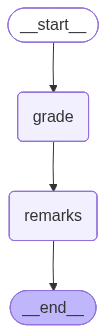

In [26]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
from pydantic import BaseModel
from langgraph.graph import StateGraph , END , START

class StudentMarks(BaseModel):
      name : str
      marks : int
      result : str = ""


def pass_student(state: StudentMarks):
    state.result = "Passed"
    return state

def fail_student(state: StudentMarks):
    state.result = "Fail"
    return state

def route_marks(state: StudentMarks):
    if state.marks >= 50:
        return "pass"

    return "fail"

builder = StateGraph(StudentMarks)

builder.add_node("pass_student", pass_student)
builder.add_node("fail_student", fail_student)
builder.add_node("route_marks", route_marks)

builder.add_edge(START,  "pass_student")
builder.add_edge("pass_student","fail_student"  )
builder.add_edge("route_marks",  END)

graph = builder.compile()

result = graph.invoke(StudentMarks(
      name  = "Akshay",
      marks  =  80  ))



print(result)



         
          

{'name': 'Akshay', 'marks': 80, 'result': 'Fail'}


In [41]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, END, START

class StudentMarks(BaseModel):
    name: str
    marks: int
    result: str = ""

def check_marks(state: StudentMarks):
    return state

def pass_student(state: StudentMarks):
    state.result = "Passed"
    return state

def fail_student(state: StudentMarks):
    state.result = "Fail"
    return state

def route_marks(state: StudentMarks):
    if state.marks >= 50:
        return "pass_student"
    return "fail_student"

builder = StateGraph(StudentMarks)

builder.add_node("check_marks", check_marks)
builder.add_node("pass_student", pass_student)
builder.add_node("fail_student", fail_student)

builder.add_edge(START, "check_marks")

builder.add_conditional_edges(
    "check_marks",
    route_marks
)

builder.add_edge("pass_student", END)
builder.add_edge("fail_student", END)

graph = builder.compile()

result = graph.invoke(
    StudentMarks(
        name="Akshay",
        marks=50
    )
)

print(result)

{'name': 'Akshay', 'marks': 50, 'result': 'Passed'}
